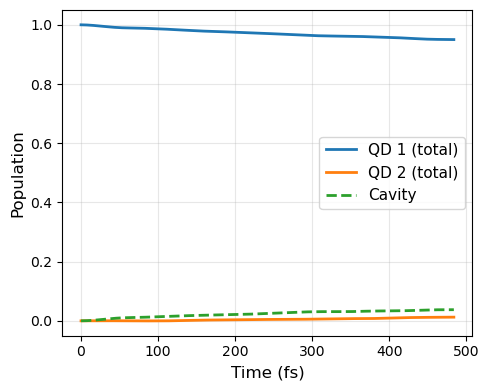

Max populations:
  QD 1: 1
  QD 2: 0.0123448
  Cavity: 0.0375505

Total population (should be ~1): 1


In [2]:
#!/usr/bin/env python3
"""
Read and plot population data from pop.out.

State ordering for this TC example:
- States 0-3: QD 1 exciton states
- States 4-7: QD 2 exciton states
- State 8: cavity photon state
"""

import numpy as np
import matplotlib.pyplot as plt

autos = 2.4188843265857e-17
n_qd = 2
nstate_per_qd = 4
n_cavity = 1
n_qd_states = n_qd * nstate_per_qd

data = np.loadtxt("pop.out")
time = data[:, 0] * autos * 1e15  # au to fs
populations = data[:, 1:]
n_states = populations.shape[1]

if n_states != n_qd_states + n_cavity:
    raise ValueError(f"Expected {n_qd_states + n_cavity} states, found {n_states}")

# Extract QD and cavity populations
qd_pop = populations[:, :n_qd_states]
cavity_pop = populations[:, n_qd_states:]

# Sum population for each QD (across its nstate_per_qd states)
qd_total_pop = np.zeros((len(time), n_qd))
for qd in range(n_qd):
    start_idx = qd * nstate_per_qd
    end_idx = (qd + 1) * nstate_per_qd
    qd_total_pop[:, qd] = qd_pop[:, start_idx:end_idx].sum(axis=1)

fig, ax = plt.subplots(figsize=(5, 4))

# Plot total population for each QD
for qd in range(n_qd):
    ax.plot(time, qd_total_pop[:, qd], label=f"QD {qd + 1} (total)", linewidth=2)

# Plot cavity population
ax.plot(time, cavity_pop[:, 0], label="Cavity", linewidth=2, linestyle='--')

ax.set_xlabel("Time (fs)", fontsize=12)
ax.set_ylabel("Population", fontsize=12)
#ax.set_title("Population dynamics: QD states and cavity", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Max populations:")
for qd in range(n_qd):
    print(f"  QD {qd + 1}: {qd_total_pop[:, qd].max():.6g}")
print(f"  Cavity: {cavity_pop[:, 0].max():.6g}")
print(f"\nTotal population (should be ~1): {(qd_total_pop.sum(axis=1) + cavity_pop.sum(axis=1)).mean():.6g}")


In [7]:
np.shape(qd_pop[:, 0:4]),qd_pop[0, 0:4]

((501, 4), array([0.35      , 0.30382813, 0.30007812, 0.04609375]))

array([0.35      , 0.30382813, 0.30007812, 0.04609375])